In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from scipy.spatial.distance import cdist # Nearest neighbor classification
import altair as alt


## Load Yale Faces Dataset

Number of persons: 15

n_train = 4, n_test = 7
Training set: 60 images
Test set: 105 images
Feature dimension: 77760
Image size: (243, 320)
Training matrix: (60, 77760), Test matrix: (105, 77760)


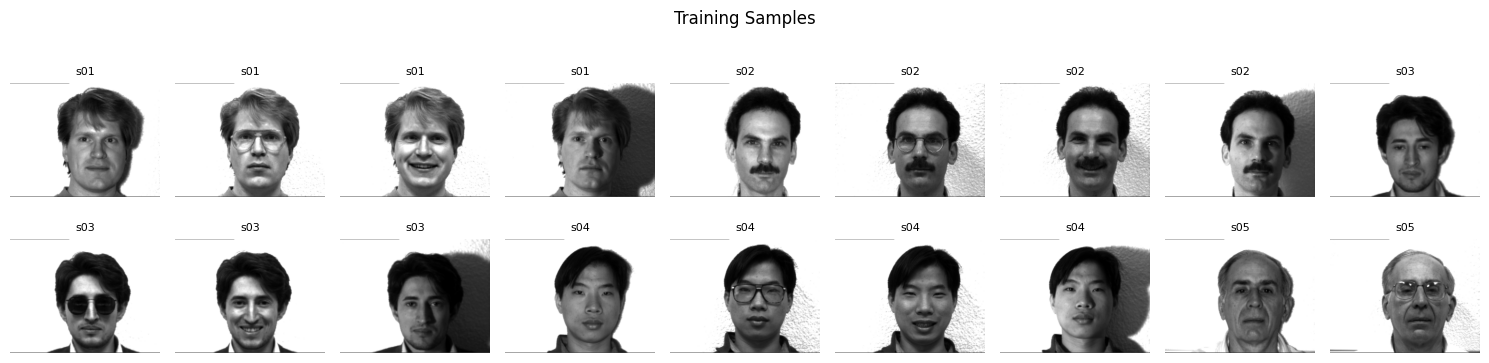

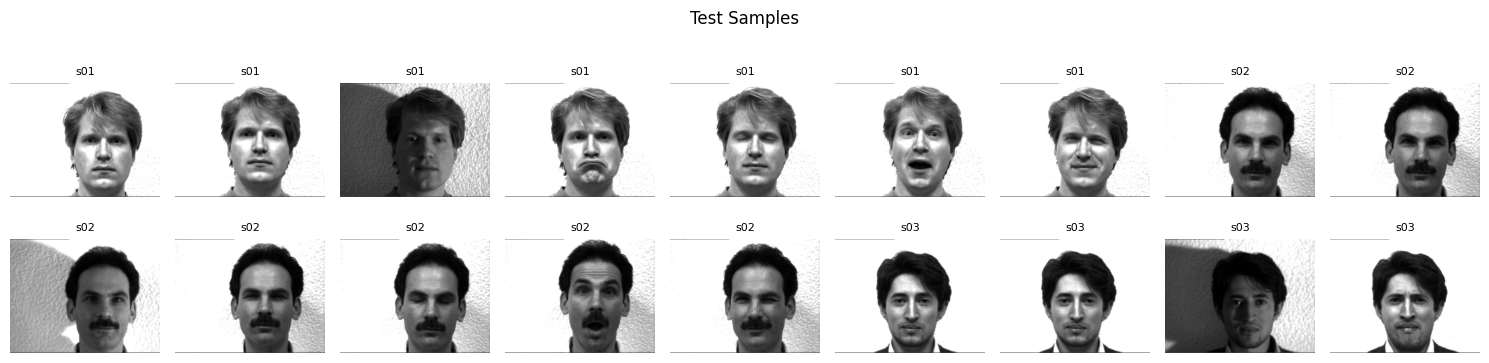

In [3]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train):
    """
    Split data: first n_train images for training, rest for testing.
    Adjust n_train to control how many images per person are used for training.
    Each person has 11 images, so n_test = 11 - n_train.
    """
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        train_imgs.extend(imgs[:n_train])
        train_labels.extend([label] * n_train)
        test_imgs.extend(imgs[n_train:])
        test_labels.extend([label] * (len(imgs) - n_train))

    return train_imgs, train_labels, test_imgs, test_labels


# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")
# for label, imgs in persons.items():
#    print(f"  {label}: {len(imgs)} images, size {imgs[0].shape}")

n_train = 4 # example : as there are 4 training image for each person

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f"\nn_train = {n_train}, n_test = {11 - n_train}")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(2, 9, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(2, 9, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

## Compute mean face and eigenfaces under different n_train

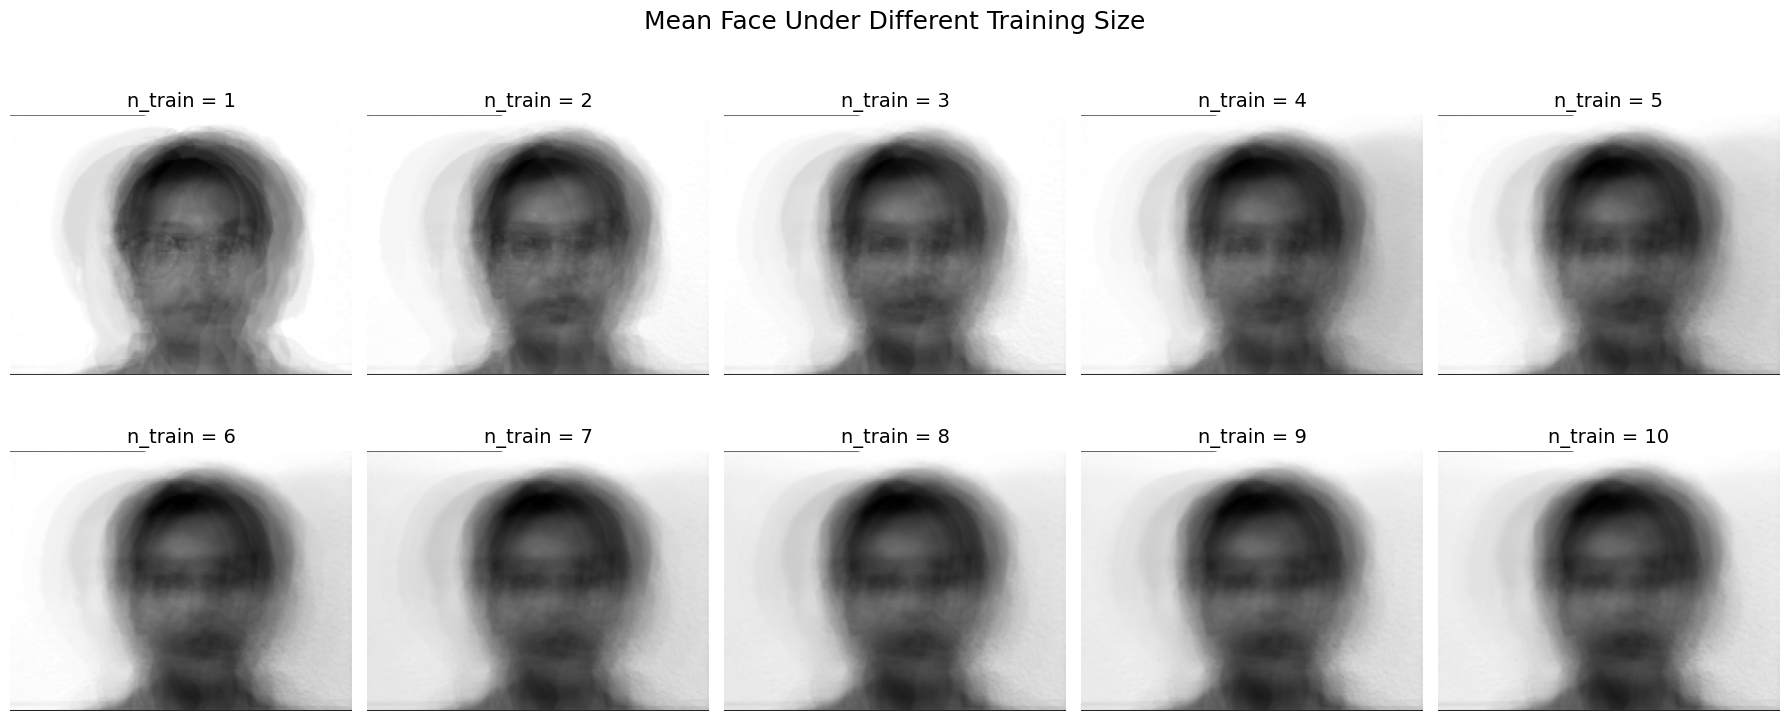

In [4]:
n_train_list = list(range(1, 11))
mean_faces = []
top3_eigenfaces = []

for n_tr in n_train_list:
    tr_imgs, _, _, _ = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs[:, :3]  # only compute top 3
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # Store as small images, not full vectors
    mean_faces.append(mf.reshape(243, 320))
    top3_eigenfaces.append([evecs[:, j].reshape(243, 320) for j in range(3)])

    # Free memory
    del X_tr, X_tr_c, small_cov, evals, small_evecs, evecs



# Visualize mean faces
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, n_tr in enumerate(n_train_list):
    ax = axes[i // 5, i % 5]
    ax.imshow(mean_faces[i], cmap='gray')
    ax.set_title(f"n_train = {n_tr}", fontsize=14,)
    ax.axis('off')
plt.suptitle("Mean Face Under Different Training Size", fontsize=18)
plt.tight_layout()
plt.show()

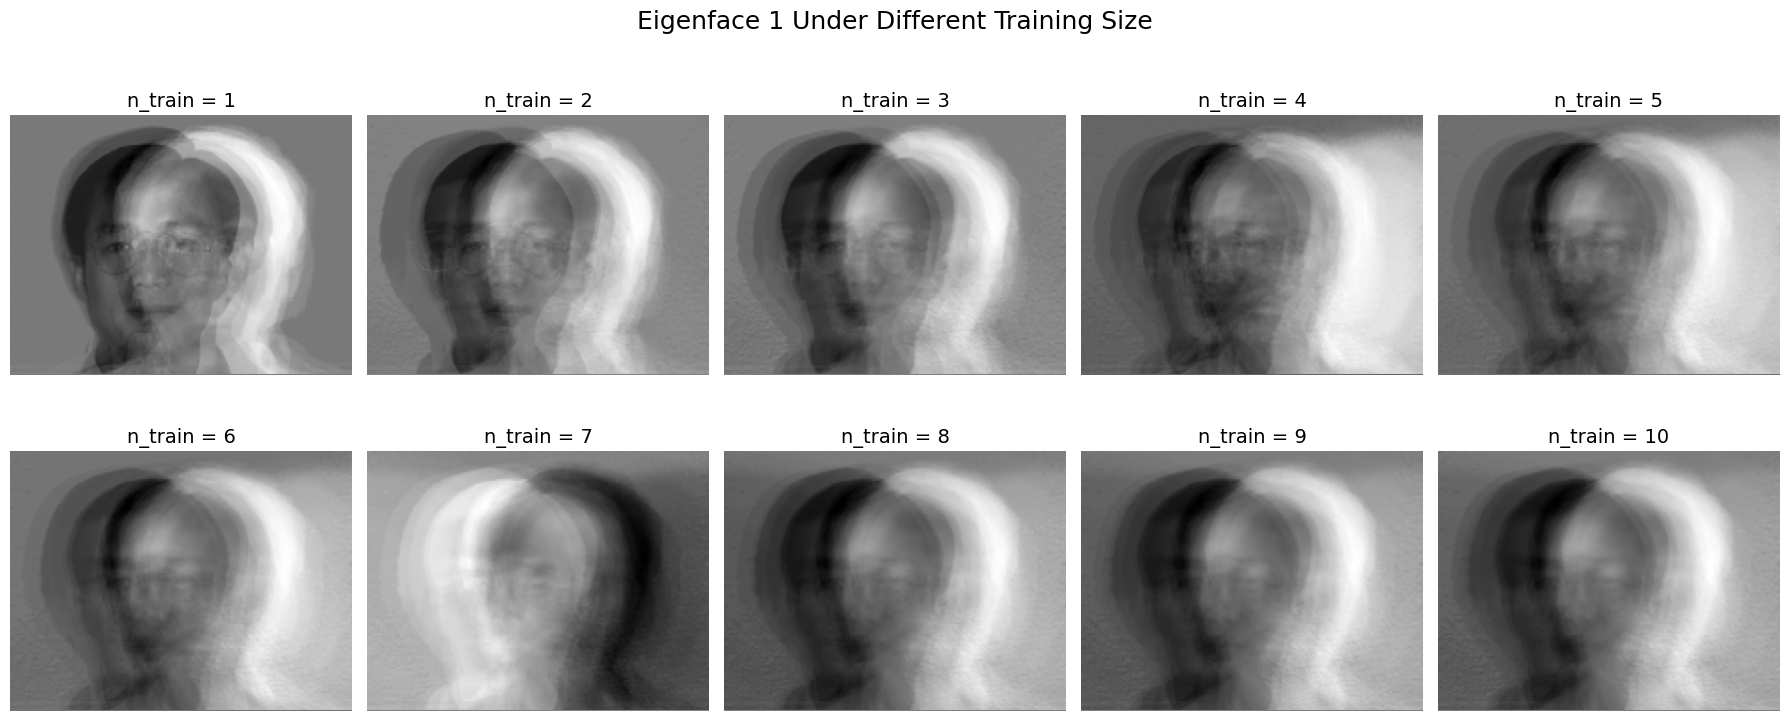

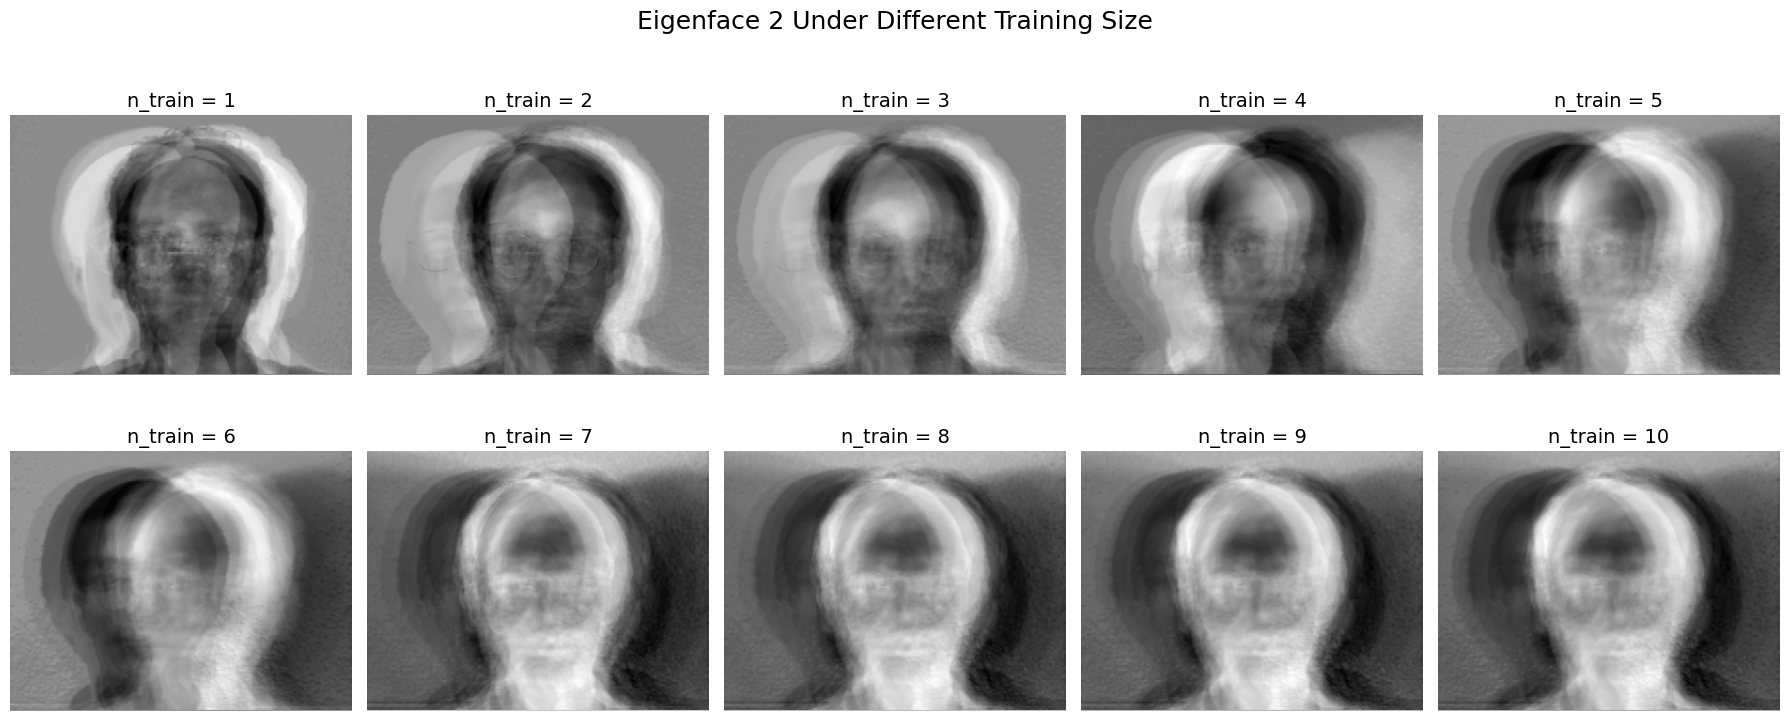

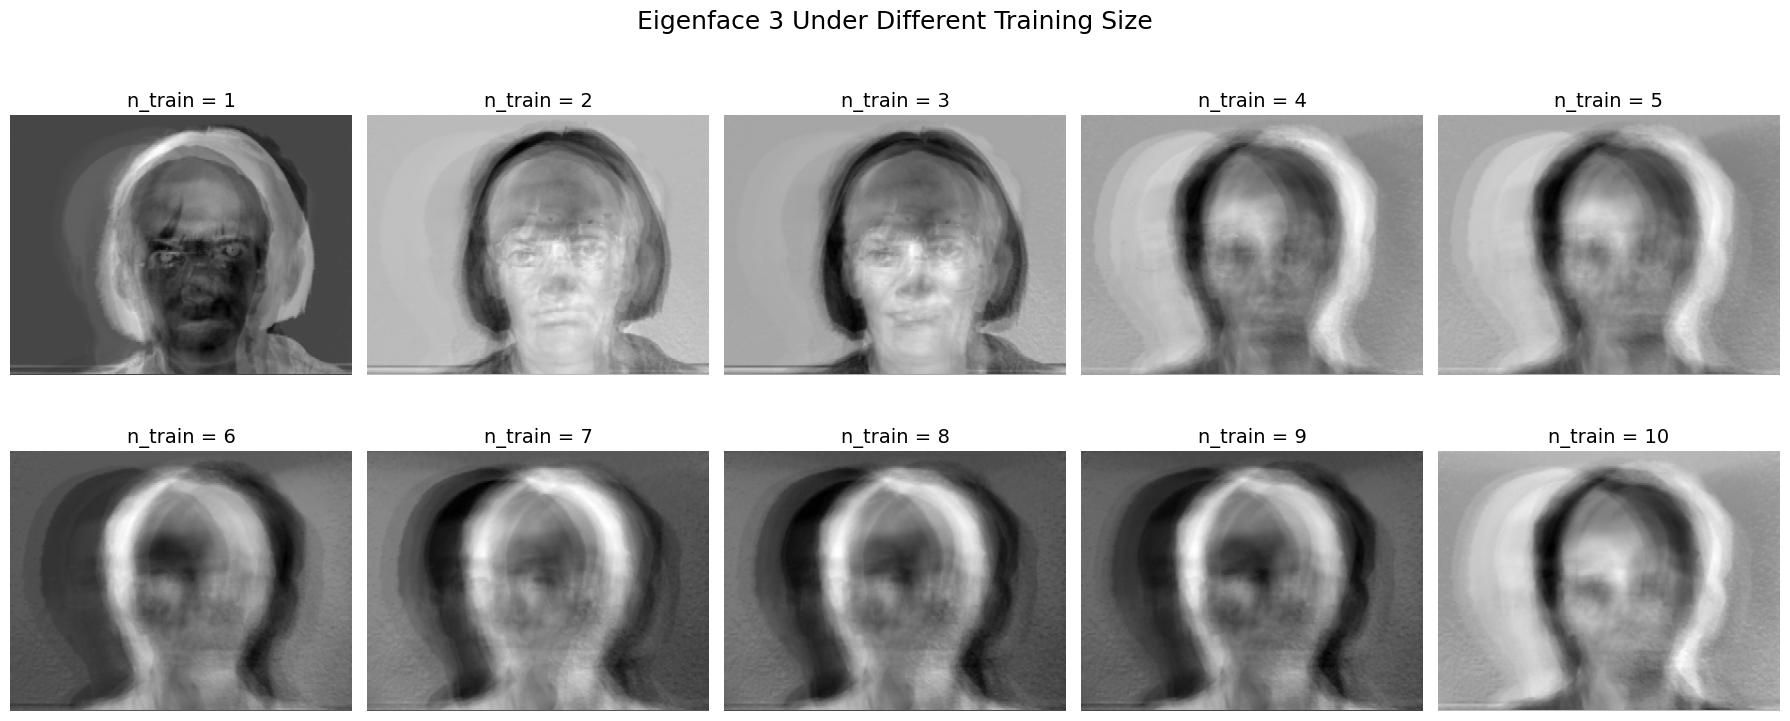

In [5]:
# Visualize top 3 eigenfaces under different n_train

for ef_idx in range(3):
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    for i, n_tr in enumerate(n_train_list):
        ax = axes[i // 5, i % 5]
        ax.imshow(top3_eigenfaces[i][ef_idx], cmap='gray')
        ax.set_title(f"n_train = {n_tr}", fontsize=14)
        ax.axis('off')
    plt.suptitle(f"Eigenface {ef_idx + 1} Under Different Training Size", fontsize=18)
    plt.tight_layout()
    plt.show()

## Cumulative Variance Curve under different n_train

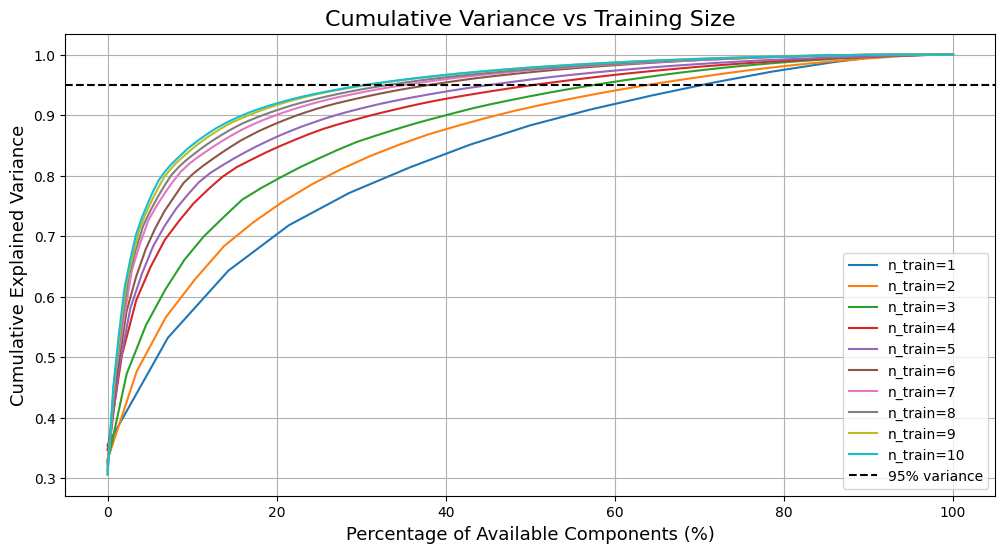

Components needed for 95% variance:
  n_train =  1 | k_95 =  11 | max components = 15
  n_train =  2 | k_95 =  20 | max components = 30
  n_train =  3 | k_95 =  27 | max components = 45
  n_train =  4 | k_95 =  31 | max components = 60
  n_train =  5 | k_95 =  35 | max components = 75
  n_train =  6 | k_95 =  35 | max components = 90
  n_train =  7 | k_95 =  38 | max components = 105
  n_train =  8 | k_95 =  41 | max components = 120
  n_train =  9 | k_95 =  43 | max components = 135
  n_train = 10 | k_95 =  47 | max components = 150


In [ ]:
n_train_list = list(range(1, 11))
cum_var_data = {}
k95_data = {}

for n_tr in n_train_list:
    tr_imgs, _, _, _ = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])

    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf

    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, _ = np.linalg.eigh(small_cov)
    evals = np.sort(evals)[::-1]

    ratio = evals / np.sum(evals)
    cum_var = np.cumsum(ratio)
    k95 = np.argmax(cum_var >= 0.95) + 1

    cum_var_data[n_tr] = cum_var
    k95_data[n_tr] = k95

    del X_tr, X_tr_c, small_cov, evals

# Plot cumulative variance curves (percentage of available components)
plt.figure(figsize=(12, 6))
for n_tr in n_train_list:
    cv = cum_var_data[n_tr]
    x_pct = np.linspace(0, 100, len(cv))
    plt.plot(x_pct, cv, label=f"n_train={n_tr}")
plt.axhline(y=0.95, color='k', linestyle='--', linewidth=1.5, label='95% variance')
plt.xlabel("Percentage of Available Components (%)", fontsize=13)
plt.ylabel("Cumulative Explained Variance", fontsize=13)
plt.title("Cumulative Variance vs Training Size", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

# Print k_95 for each n_train
print("Components needed for 95% variance:")
for n_tr in n_train_list:
    max_k = len(cum_var_data[n_tr])
    print(f"  n_train = {n_tr:>2d} | k_95 = {k95_data[n_tr]:>3d} | max components = {max_k}")

In [ ]:
# Altair Slider
# Build dataframe
rows = []
for n_tr in n_train_list:
    cv = cum_var_data[n_tr]
    x_pct = np.linspace(0, 100, len(cv))
    for j in range(len(cv)):
        rows.append({
            'n_train': n_tr,
            'pct_components': x_pct[j],
            'cum_variance': cv[j]
        })

df = pd.DataFrame(rows)

# Slider for minimum n_train
slider = alt.binding_range(min=1, max=10, step=1, name='Min n_train: ')
selection = alt.param(name='min_ntrain', value=1, bind=slider)
train_select = alt.selection_point(fields= ['n_train'], empty = 'all')

# Chart
chart = alt.Chart(df).mark_line(point=False).encode(
    x=alt.X('pct_components:Q', title='Percentage of Available Components (%)'),
    y=alt.Y('cum_variance:Q', title='Cumulative Explained Variance', scale=alt.Scale(domain=[0.3, 1.05])),
    color=alt.Color('n_train:N', title='n_train',
        sort=list(range(1, 11)),
        scale=alt.Scale(
            domain=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            range=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        )
    ),
    tooltip=[
        alt.Tooltip('n_train:N', title='n_train'),
        alt.Tooltip('pct_components:Q', title='Components %', format='.1f'),
        alt.Tooltip('cum_variance:Q', title='Variance', format='.4f')
    ]
).add_params(
    selection
).transform_filter(
    alt.datum.n_train >= selection
).properties(
    title='Cumulative Variance vs Training Size',
    width=700,
    height=400
)

# 95% reference line
rule = alt.Chart(pd.DataFrame({'y': [0.95]})).mark_rule(
    strokeDash=[5, 5], color='black', strokeWidth=1.5
).encode(y='y:Q')

(chart + rule)

alt.LayerChart(...)

## Eigen decomposition

Small covariance matrix shape: (150, 150)
Eigenvectors shape: (77760, 150)


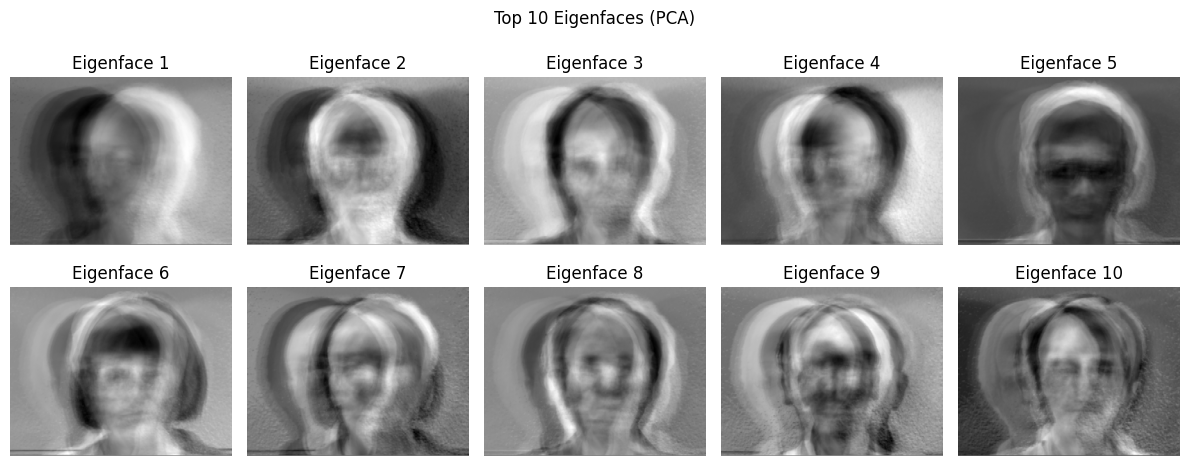

In [ ]:
n = X_train_centered.shape[0]
small_cov = (X_train_centered @ X_train_centered.T) / (n - 1)
print(f"Small covariance matrix shape: {small_cov.shape}")

eigenvalues, small_eigvecs = np.linalg.eigh(small_cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
small_eigvecs = small_eigvecs[:, idx]

eigenvectors = X_train_centered.T @ small_eigvecs
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

print(f"Eigenvectors shape: {eigenvectors.shape}")

# Visualize some eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(eigenvectors[:, i].reshape(img_shape), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.suptitle("Top 10 Eigenfaces (PCA)")
plt.tight_layout()
plt.show()

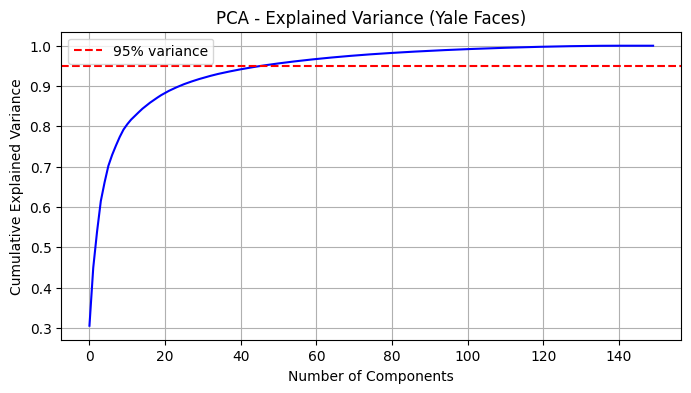

Components needed for 95% variance: 47


In [ ]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance, 'b-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance (Yale Faces)")
plt.legend()
plt.grid(True)
plt.show()

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {k_95}")

n_train = 2 | Total training: 30 | k_95 = 20 | Max k = 30 | Accuracy: 62.22%
n_train = 3 | Total training: 45 | k_95 = 27 | Max k = 45 | Accuracy: 80.00%
n_train = 5 | Total training: 75 | k_95 = 35 | Max k = 75 | Accuracy: 90.00%
n_train = 7 | Total training: 105 | k_95 = 38 | Max k = 105 | Accuracy: 96.67%
n_train = 9 | Total training: 135 | k_95 = 43 | Max k = 135 | Accuracy: 96.67%


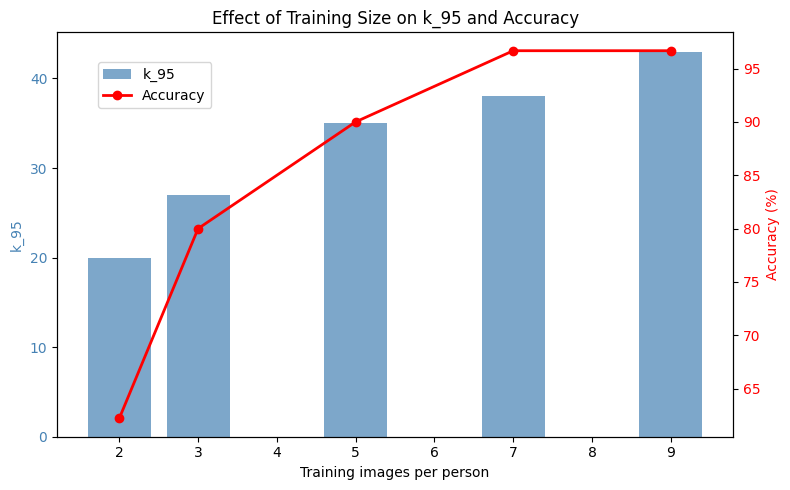

In [ ]:
# ============================================================
# Compare k_95 under different training sizes
# ============================================================

n_train_list = [2, 3, 5, 7, 9]
results = []

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])

    # Center
    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf
    X_te_c = X_te - mf

    # Small matrix trick
    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # Cumulative variance
    ratio = evals / np.sum(evals)
    cum_var = np.cumsum(ratio)
    k95 = np.argmax(cum_var >= 0.95) + 1

    # Accuracy at k_95
    W = evecs[:, :k95]
    X_tr_p = X_tr_c @ W
    X_te_p = X_te_c @ W
    dists = cdist(X_te_p, X_tr_p, metric='euclidean')
    preds = np.array(tr_labels)[np.argmin(dists, axis=1)]
    acc = np.mean(preds == np.array(te_labels)) * 100

    results.append({'n_train': n_tr, 'total_train': n * 1, 'k_95': k95, 'max_k': n, 'accuracy': acc})
    print(f"n_train = {n_tr} | Total training: {X_tr.shape[0]} | k_95 = {k95} | Max k = {X_tr.shape[0]} | Accuracy: {acc:.2f}%")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

n_trains = [r['n_train'] for r in results]
k95s = [r['k_95'] for r in results]
accs = [r['accuracy'] for r in results]

ax1.bar(n_trains, k95s, color='steelblue', alpha=0.7, label='k_95')
ax1.set_xlabel('Training images per person')
ax1.set_ylabel('k_95', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(n_trains, accs, 'ro-', linewidth=2, label='Accuracy')
ax2.set_ylabel('Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Effect of Training Size on k_95 and Accuracy')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

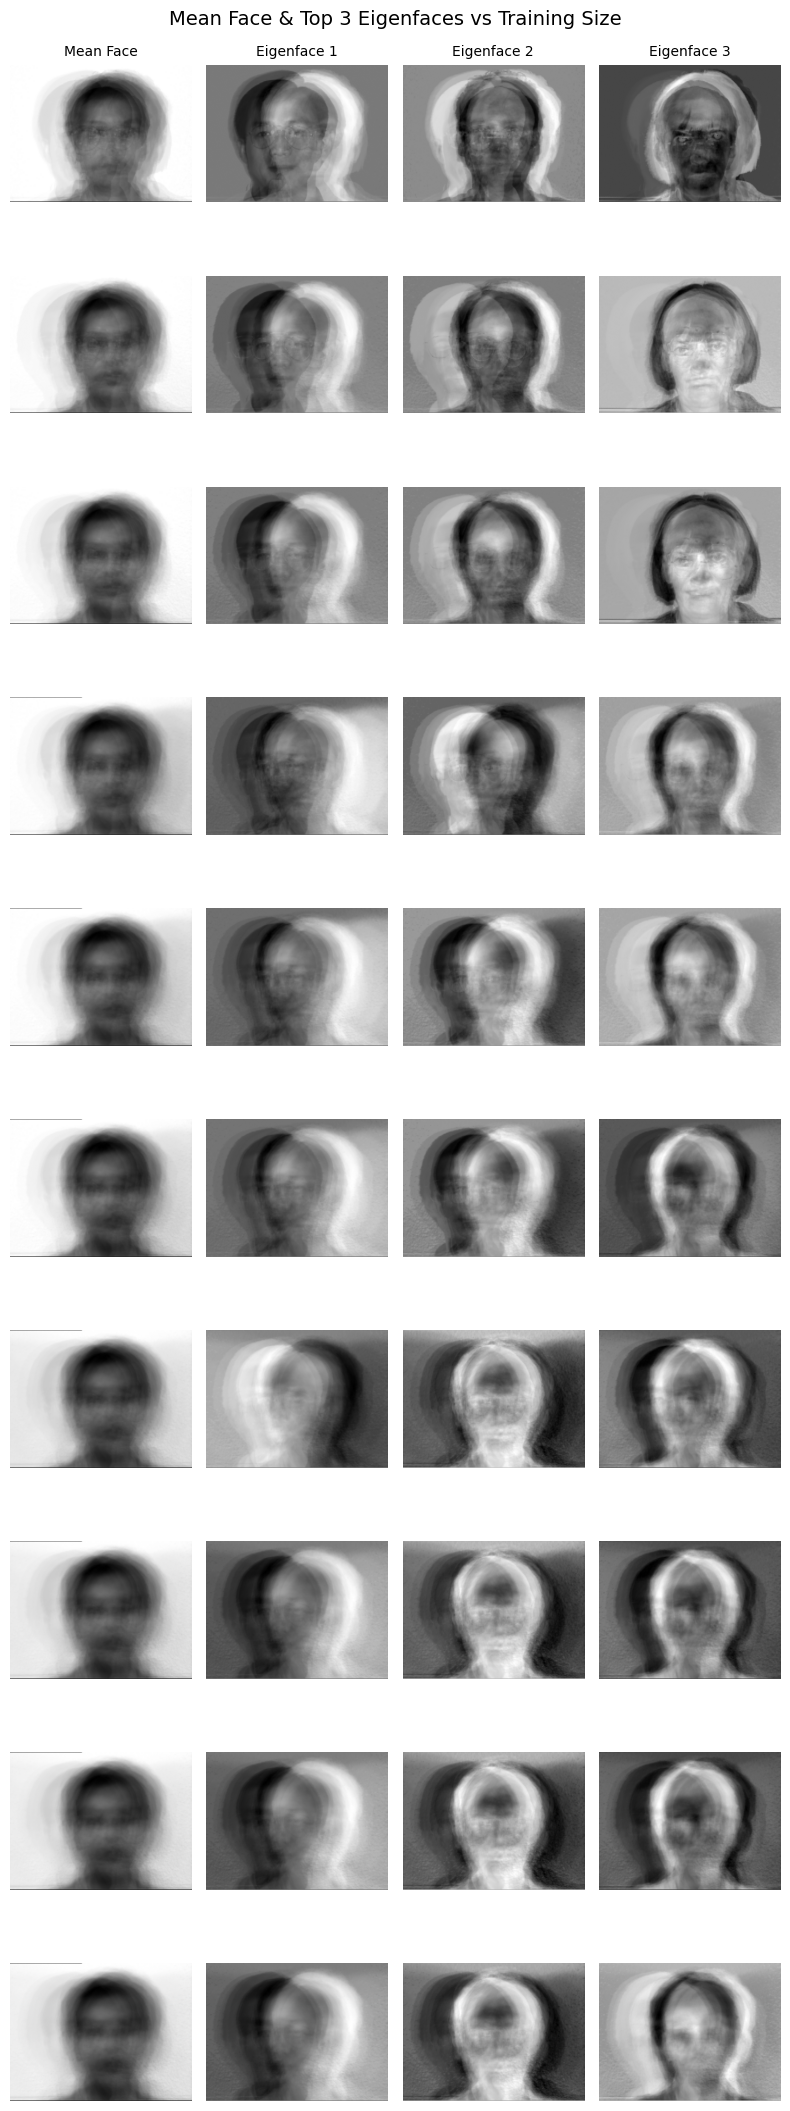

In [ ]:
# ============================================================
# Compare Mean Face and Top 3 Eigenfaces under different n_train
# ============================================================

n_train_list = list(range(1, 11))

fig, axes = plt.subplots(len(n_train_list), 4, figsize=(8, 22))

for row, n_tr in enumerate(n_train_list):
    tr_imgs, tr_labels, _, _ = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])

    # Mean face
    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf

    # Eigen decomposition
    n = X_tr_c.shape[0]
    small_cov = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, small_evecs = np.linalg.eigh(small_cov)
    idx = np.argsort(evals)[::-1]
    small_evecs = small_evecs[:, idx]
    evecs = X_tr_c.T @ small_evecs
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    # Plot mean face
    axes[row, 0].imshow(mf.reshape(img_shape), cmap='gray')
    axes[row, 0].set_ylabel(f"n={n_tr}", fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

    # Plot top 3 eigenfaces
    for j in range(3):
        axes[row, j+1].imshow(evecs[:, j].reshape(img_shape), cmap='gray')
        axes[row, j+1].axis('off')

# Column titles
axes[0, 0].set_title("Mean Face", fontsize=10)
axes[0, 1].set_title("Eigenface 1", fontsize=10)
axes[0, 2].set_title("Eigenface 2", fontsize=10)
axes[0, 3].set_title("Eigenface 3", fontsize=10)

plt.suptitle("Mean Face & Top 3 Eigenfaces vs Training Size", fontsize=14)
plt.tight_layout()
plt.show()